# CODIGO DE APLICACIÓN A UN DATASET DE OTRO PERIODO

Vamos a usar el código de ejecución para diferentes periodos de cara a saber si realiza las previsiones correctamente teniendo los ficheros. En este caso lo haremos sobre Diciembre 2024

*NOTA: Para poder usar este código de ejecución hay que lanzarlo desde exactamente el mismo entorno en el que fue realizado el proyecto.*

*Se puede instalar ese entorno en la nueva máquina usando el environment.yml que creamos en el set up del proyecto*

*Copiar el 007_airbnb.yml que tenemos en la carpeta Documentos, al directorio y en el terminal o anaconda prompt ejecutar:*

conda env create --file 007_airbnb.yml --name 007_airbnb

In [1]:
#Importamos los paquetes necesarios
import cloudpickle
import pandas as pd
import sqlalchemy as sa
from janitor import clean_names


# PRECIO_M2 IDEALISTA
#Ruta del proyecto
ruta_proyecto = 'C:/Users/Oscar/OneDrive - FM4/Escritorio/EVOLVE\Data Science/Proyecto-Master-DataScience-Evolve-OscarFraile'

#Nombre del fichero de datos
nombre_fichero_datos = 'precios_idealista_Dic24.csv'

#Cargar los datos
ruta_completa = ruta_proyecto + '/02_Datos/01_Originales/' + nombre_fichero_datos
precio_m2 = pd.read_csv(ruta_completa)

#Pipeline con las modificaciones hechas en la tabla
nombre_pipe = 'pipe_idealista.pickle'
ruta_pipe = ruta_proyecto + '/04_Modelos/' + nombre_pipe
with open(ruta_pipe, mode='rb') as file:
    pipe_idealista = cloudpickle.load(file)

precio_m2 = pipe_idealista.transform(precio_m2)


# LISTINGS AIRBNB
#Ruta del proyecto
ruta_proyecto = 'C:/Users/Oscar/OneDrive - FM4/Escritorio/EVOLVE\Data Science/Proyecto-Master-DataScience-Evolve-OscarFraile'

#Nombre del fichero de datos
nombre_fichero_datos = 'listings.csv'

#Cargar los datos
ruta_completa = ruta_proyecto + '/02_Datos/01_Originales/Airbnb_Dic24/' + nombre_fichero_datos
listings = pd.read_csv(ruta_completa)

# LISTINGS_DET AIRBNB
#Ruta del proyecto
ruta_proyecto = 'C:/Users/Oscar/OneDrive - FM4/Escritorio/EVOLVE\Data Science/Proyecto-Master-DataScience-Evolve-OscarFraile'

#Nombre del fichero de datos
nombre_fichero_datos = 'listings_det.csv'

#Cargar los datos
ruta_completa = ruta_proyecto + '/02_Datos/01_Originales/Airbnb_Dic24/' + nombre_fichero_datos
listings_det = pd.read_csv(ruta_completa)

#Pipeline con las modificaciones hechas en la tabla
nombre_pipe = 'pipe_preparacion_df.pickle'
ruta_pipe = ruta_proyecto + '/04_Modelos/' + nombre_pipe
with open(ruta_pipe, mode='rb') as file:
    pipe_preparacion_df = cloudpickle.load(file)

df = pipe_preparacion_df.transform((listings_det, listings, precio_m2))

#Pipeline con las modificaciones hechas en la tabla
nombre_pipe = 'pipe_calidad_datos.pickle'
ruta_pipe = ruta_proyecto + '/04_Modelos/' + nombre_pipe
with open(ruta_pipe, mode='rb') as file:
    pipe_calidad_datos = cloudpickle.load(file)
    
df = pipe_calidad_datos.transform(df)

#Pipeline con las modificaciones hechas en la tabla
nombre_pipe = 'pipe_gestion_variables.pickle'
ruta_pipe = ruta_proyecto + '/04_Modelos/' + nombre_pipe
with open(ruta_pipe, mode='rb') as file:
    pipe_gestion_variables = cloudpickle.load(file)

df = pipe_gestion_variables.transform(df)

con = sa.create_engine('sqlite:///C:/Users/Oscar/OneDrive - FM4/Escritorio/EVOLVE\Data Science/Proyecto-Master-DataScience-Evolve-OscarFraile/02_Datos/01_Originales/airbnb2025.db')

extras_df = df[['id', 'precio_total', 'm2', 'precio_m2']].copy()
extras_df.to_sql('extras_df', con = con, if_exists = 'replace')

variables_finales = [
'accommodates',
'availability_30',
'availability_365',
'availability_90',
'bedrooms',
'bed',
'calculated_host_listings_count',
'has_availability',
'host_response_rate',
'host_response_time',
'instant_bookable',
'maximum_nights',
'neighbourhood_group',
'price',
'property_type',
'room_type',
'license',
'bathrooms',
'air',
'allowed',
'cleaning',
'hot water iron',
'iron',
'microwave',
'parking',
'refrigerator',
'shampoo',
'tv washer',
'wifi kitchen',
'neighbourhood_cleansed',
'and silverware',
'body',
'clothing',
'clothing storage',
'coffee',
'elevator',
'hair',
'host_identity_verified',
'host_verifications',
'kitchen essentials',
'allowed',
'basics',
'beds',
'dryer bed',
'hair dryer',
'maker',
'microwave hangers',
'oven',
'stove',
'review_scores_rating',
'review_scores_accuracy',
'review_scores_cleanliness',
'review_scores_checkin',
'review_scores_communication',
'review_scores_location',
'review_scores_value',
'host_is_superhost',
'bathrooms_text',
'precio_m2',
'latitude',
'longitude',
'amenities',
'number_of_reviews']

df = df[variables_finales]

nombre_pipe_ejecucion = 'pipe_ejecucion.pickle'
ruta_pipe_ejecucion = ruta_proyecto + '/04_Modelos/' + nombre_pipe_ejecucion
with open(ruta_pipe_ejecucion, mode='rb') as file:
   pipe_ejecucion = cloudpickle.load(file)

scoring = pipe_ejecucion.predict_proba(df)[:, 1]

df['rentabilidad_predicha'] = scoring
df['rentable'] = df['rentabilidad_predicha'] > 0.5
df['id'] = extras_df['id']
df['precio_total'] = extras_df['precio_total']
df['m2'] = extras_df['m2']

# Rentabilidad del inmueble
ocupacion_media = 0.60  # 60% de ocupación anual
coste_operativo_pct = 0.30  # 30% de los ingresos
df['ingresos_brutos_anuales'] = df['precio_total'] * df['availability_365'] * ocupacion_media
df['beneficio_neto_anual'] = round(df['ingresos_brutos_anuales'] * (1 - coste_operativo_pct),2)

# Estimar el precio de mercado de la vivienda
df['precio_estimado'] = df['precio_m2'] * df['m2']

# Rentabilidad anual en %
df['rentabilidad_anual_pct'] = round((df['beneficio_neto_anual'] / df['precio_estimado']) * 100,2)

df.set_index('id', inplace = True)

c:\Users\Oscar\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator FunctionTransformer from version 1.3.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Oscar\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.3.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Oscar\AppData\Local\Temp\ipykernel_7188\3667475308.py:5: FutureWarning: The default value of regex will change from True to False in a futur

In [2]:
df.isna().sum().sort_values(ascending=False)

accommodates                 0
maker                        0
review_scores_cleanliness    0
review_scores_accuracy       0
review_scores_rating         0
                            ..
microwave                    0
iron                         0
hot water iron               0
cleaning                     0
rentabilidad_anual_pct       0
Length: 71, dtype: int64

In [3]:
#Mostrar el máximo de columnas posibles de una tabla
pd.set_option('display.max_columns', None) #Número de columnas que deben verse. None = Máx
df[['neighbourhood_group','room_type','review_scores_value','price','precio_estimado','beneficio_neto_anual','rentabilidad_anual_pct']].loc[(df.beneficio_neto_anual>0)]

,neighbourhood_group,room_type,review_scores_value,price,precio_estimado,beneficio_neto_anual,rentabilidad_anual_pct
id,,,,,,,
21853,Latina,Private room,4.67,31.0,138600,1874.88,1.35
62423,Centro,Private room,4.58,69.0,308500,11283.48,3.66
70073,Centro,Entire home/apt,4.06,80.0,308500,9172.80,2.97
70310,Centro,Entire home/apt,4.11,64.0,308500,8037.12,2.61
72150,Centro,Entire home/apt,4.45,159.0,555300,12020.40,2.16
...,...,...,...,...,...,...,...
1308797105765566482,Moncloa,Entire home/apt,0.00,258.0,243800,39551.40,16.22
1308811268356474614,Ciudad Lineal,Private room,0.00,85.0,183800,13030.50,7.09
1308816654087147793,Latina,Entire home/apt,0.00,258.0,138600,37926.00,27.36


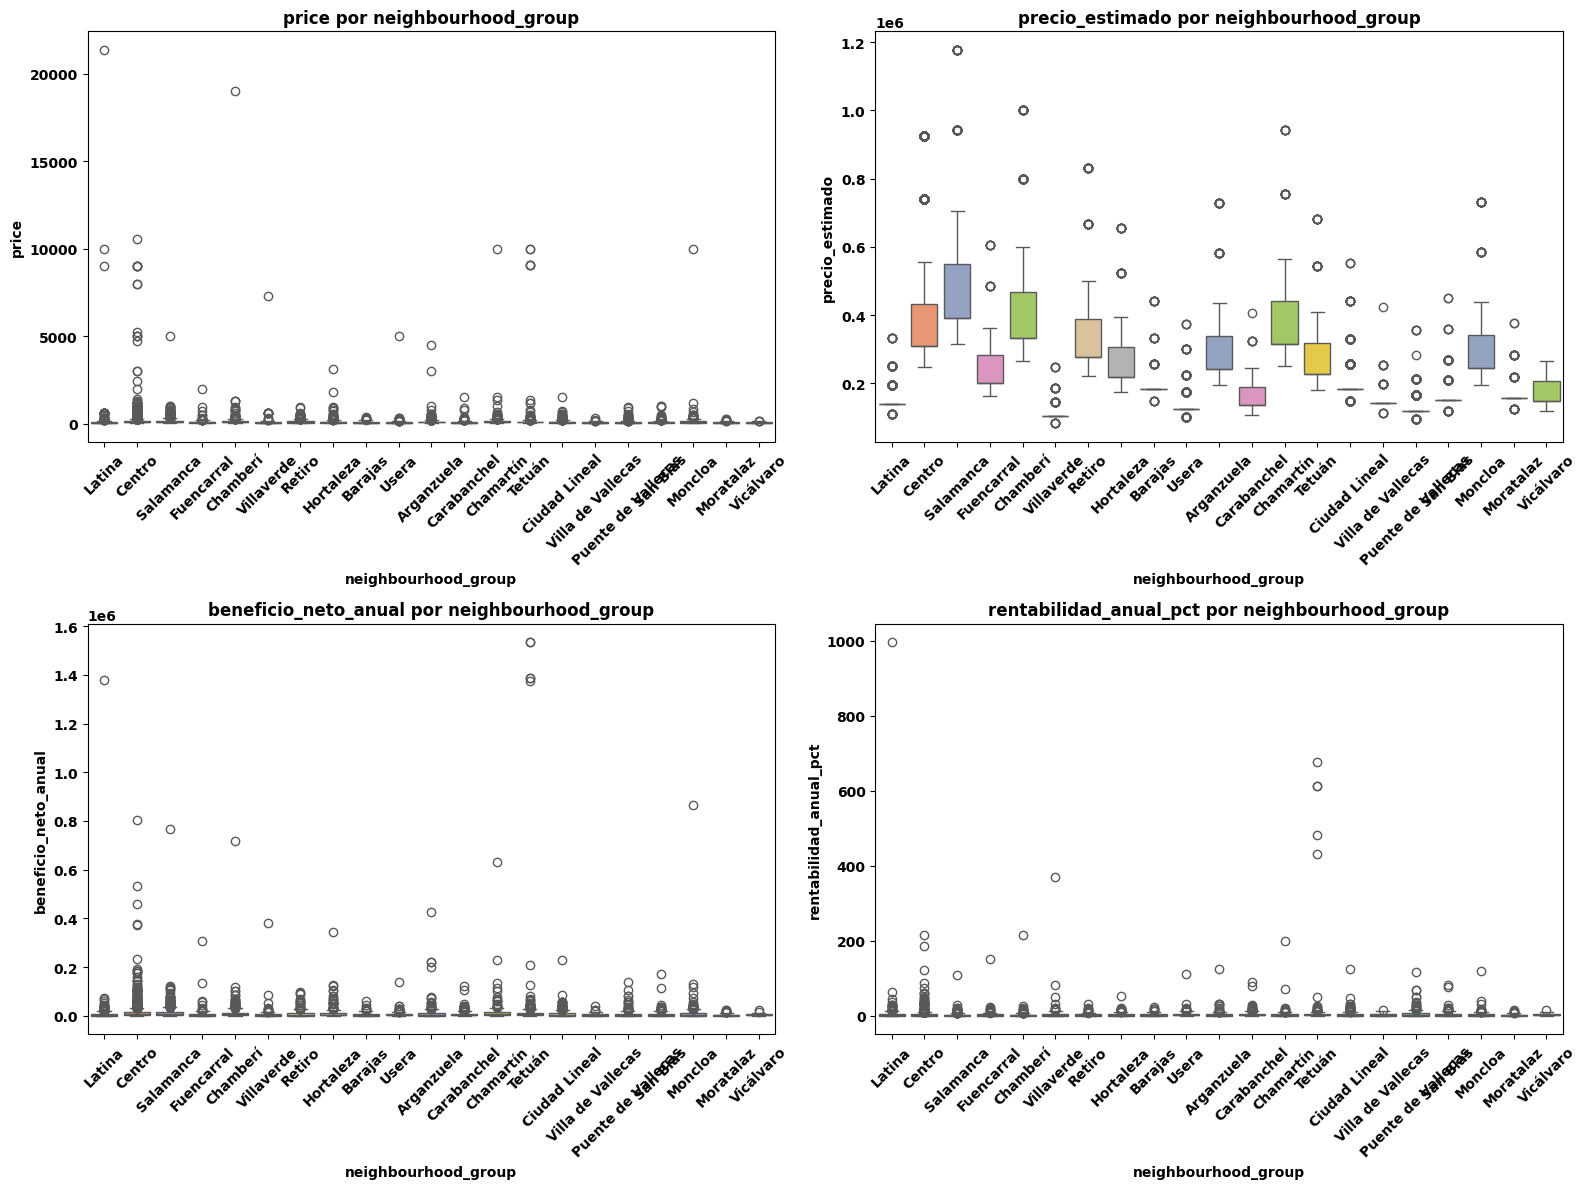

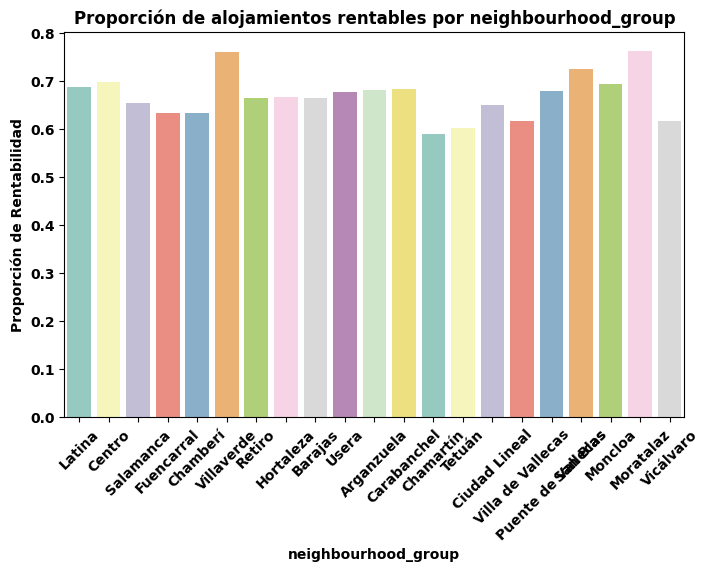

In [4]:
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

# Asegúrate de que los gráficos se vean en notebooks
%matplotlib inline  

# Lista de variables a graficar
variables = ['price', 'precio_estimado', 'beneficio_neto_anual', 'rentabilidad_anual_pct']

# Tamaño del gráfico
plt.figure(figsize=(16, 12))

# Graficar cada variable con boxplot por neighbourhood_group
for i, var in enumerate(variables, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='neighbourhood_group', y=var, data=df, palette='Set2')
    plt.title(f'{var} por neighbourhood_group')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Gráfico de proporción de "rentable" por grupo
plt.figure(figsize=(8, 5))
sns.barplot(
    x='neighbourhood_group',
    y='rentable',
    data=df,
    estimator=lambda x: sum(x) / len(x),
    ci=None,
    palette='Set3'
)
plt.ylabel('Proporción de Rentabilidad')
plt.title('Proporción de alojamientos rentables por neighbourhood_group')
plt.xticks(rotation=45)
plt.show()

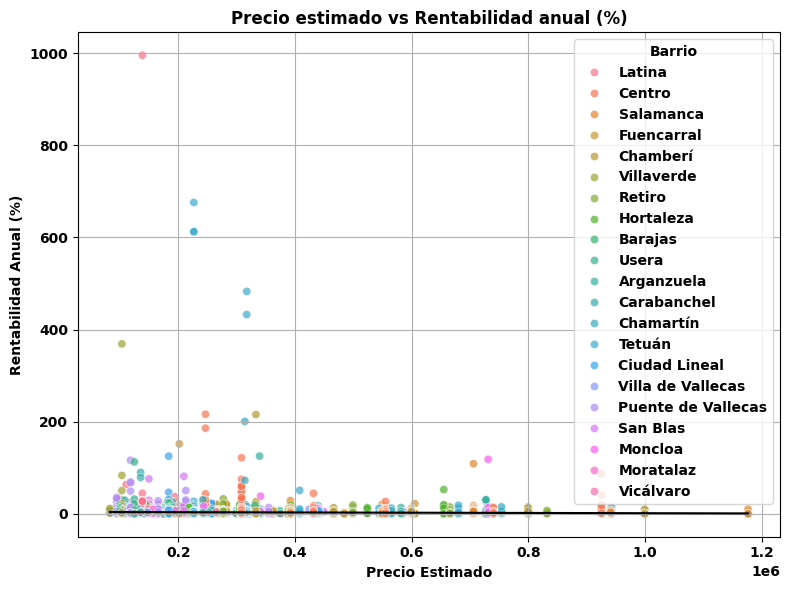

Coeficiente de correlación: -0.03


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot con línea de tendencia
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='precio_estimado', y='rentabilidad_anual_pct', hue='neighbourhood_group', alpha=0.7)
sns.regplot(data=df, x='precio_estimado', y='rentabilidad_anual_pct', scatter=False, color='black', line_kws={"linewidth":1.5})
plt.title('Precio estimado vs Rentabilidad anual (%)')
plt.xlabel('Precio Estimado')
plt.ylabel('Rentabilidad Anual (%)')
plt.legend(title='Barrio')
plt.grid(True)
plt.tight_layout()
plt.show()

# Correlación entre ambas variables
correlacion = df['precio_estimado'].corr(df['rentabilidad_anual_pct'])
print(f'Coeficiente de correlación: {correlacion:.2f}')

In [6]:
top_10 = df[['neighbourhood_group', 'price', 'precio_estimado', 'beneficio_neto_anual', 'rentabilidad_anual_pct']].sort_values(by='rentabilidad_anual_pct', ascending=False).head(50)
top_10

,neighbourhood_group,price,precio_estimado,beneficio_neto_anual,rentabilidad_anual_pct
id,,,,,
660139500537852378,Latina,9000.0,138600,1379700.00,995.45
49742460,Tetuán,9999.0,226800,1532846.70,675.86
1060272657994681485,Tetuán,9059.0,226800,1388744.70,612.32
1060276046192183071,Tetuán,9059.0,226800,1388744.70,612.32
612030162376917657,Tetuán,9999.0,317520,1532846.70,482.76
1060276271097283207,Tetuán,9059.0,317520,1373525.58,432.58
29759929,Villaverde,7273.0,103500,381832.50,368.92
912246660647527893,Centro,4720.0,246800,533265.60,216.07
1121959561231187404,Chamberí,19000.0,333250,718200.00,215.51


In [7]:
df.head(5)

,accommodates,availability_30,availability_365,availability_90,bedrooms,bed,calculated_host_listings_count,has_availability,host_response_rate,host_response_time,instant_bookable,maximum_nights,neighbourhood_group,price,property_type,room_type,license,bathrooms,air,allowed,cleaning,hot water iron,iron,microwave,parking,refrigerator,shampoo,tv washer,wifi kitchen,neighbourhood_cleansed,and silverware,body,clothing,clothing storage,coffee,elevator,hair,host_identity_verified,host_verifications,kitchen essentials,allowed,basics,beds,dryer bed,hair dryer,maker,microwave hangers,oven,stove,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,host_is_superhost,bathrooms_text,precio_m2,latitude,longitude,amenities,number_of_reviews,rentabilidad_predicha,rentable,precio_total,m2,ingresos_brutos_anuales,beneficio_neto_anual,precio_estimado,rentabilidad_anual_pct
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
21853,1,0,144,0,1.0,1,2,yes,0.0,no response,f,40,Latina,31.0,Private room in rental unit,Private room,no,1.0,1,0,0,1,1,1,1,1,1,1,1,Cármenes,1,0,0,0,1,1,1,t,"['email', 'phone']",1,0,1,1.0,1,1,1,1,1,0,4.58,4.72,4.56,4.75,4.82,4.21,4.67,f,1.0,2772,40.40381,-3.74130,"[""First aid kit"", ""Wifi"", ""Kitchen"", ""Essentia...",33,0.997768,True,31.00,50,2678.400,1874.88,138600,1.35
30320,2,0,0,0,1.0,0,3,no,0.0,no response,f,180,Centro,149.0,Entire rental unit,Entire home/apt,no,1.0,1,0,0,0,0,0,0,0,0,0,0,Sol,0,0,0,0,0,1,0,f,"['email', 'phone']",0,0,0,1.0,0,0,0,0,0,0,4.63,4.71,4.88,4.82,4.78,4.90,4.69,f,1.0,6170,40.41476,-3.70418,"[""Heating"", ""Wifi"", ""TV with standard cable"", ...",172,1.000000,True,149.00,50,0.000,0.00,308500,0.00
30959,2,0,0,0,1.0,0,1,no,0.0,no response,f,730,Centro,92.0,Entire loft,Entire home/apt,no,1.0,0,1,0,0,0,0,0,0,1,0,0,Embajadores,0,0,0,0,0,1,0,f,"['email', 'phone']",0,1,0,1.0,0,0,0,0,0,0,4.38,4.14,4.38,4.63,4.63,4.88,4.25,f,1.0,6170,40.41259,-3.70105,"[""Breakfast"", ""Heating"", ""Wifi"", ""Smoking allo...",8,1.000000,True,92.00,50,0.000,0.00,308500,0.00
40916,3,0,0,0,1.0,0,3,no,0.0,no response,f,180,Centro,124.0,Entire rental unit,Entire home/apt,no,1.0,1,1,0,0,0,0,0,0,0,1,0,Universidad,0,0,0,0,0,1,0,f,"['email', 'phone']",0,1,0,2.0,0,0,0,0,0,0,4.65,4.69,4.90,4.85,4.79,4.88,4.55,f,1.0,6170,40.42247,-3.70577,"[""Heating"", ""Wifi"", ""Pets allowed"", ""Kitchen"",...",49,1.000000,True,124.00,50,0.000,0.00,308500,0.00
62423,4,13,332,59,1.0,0,3,yes,100.0,within an hour,f,30,Centro,69.0,Private room in rental unit,Private room,no,1.5,0,1,1,1,1,0,0,1,1,0,0,Justicia,1,1,0,0,0,0,1,t,"['email', 'phone']",1,1,1,2.0,0,1,0,0,0,0,4.64,4.78,4.42,4.79,4.85,4.97,4.58,f,1.5,6170,40.41884,-3.69655,"[""Books and reading material"", ""First aid kit""...",219,0.000008,False,80.92,50,16119.264,11283.48,308500,3.66


In [10]:
df['periodo'] = 'Dic24'
df

,accommodates,availability_30,availability_365,availability_90,bedrooms,bed,calculated_host_listings_count,has_availability,host_response_rate,host_response_time,instant_bookable,maximum_nights,neighbourhood_group,price,property_type,room_type,license,bathrooms,air,allowed,cleaning,hot water iron,iron,microwave,parking,refrigerator,shampoo,tv washer,wifi kitchen,neighbourhood_cleansed,and silverware,body,clothing,clothing storage,coffee,elevator,hair,host_identity_verified,host_verifications,kitchen essentials,allowed,basics,beds,dryer bed,hair dryer,maker,microwave hangers,oven,stove,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,host_is_superhost,bathrooms_text,precio_m2,latitude,longitude,amenities,number_of_reviews,rentabilidad_predicha,rentable,precio_total,m2,ingresos_brutos_anuales,beneficio_neto_anual,precio_estimado,rentabilidad_anual_pct,periodo
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
21853,1,0,144,0,1.0,1,2,yes,0.0,no response,f,40,Latina,31.0,Private room in rental unit,Private room,no,1.0,1,0,0,1,1,1,1,1,1,1,1,Cármenes,1,0,0,0,1,1,1,t,"['email', 'phone']",1,0,1,1.0,1,1,1,1,1,0,4.58,4.72,4.56,4.75,4.82,4.21,4.67,f,1.0,2772,40.403810,-3.741300,"[""First aid kit"", ""Wifi"", ""Kitchen"", ""Essentia...",33,0.997768,True,31.00,50,2678.400,1874.88,138600,1.35,Dic24
30320,2,0,0,0,1.0,0,3,no,0.0,no response,f,180,Centro,149.0,Entire rental unit,Entire home/apt,no,1.0,1,0,0,0,0,0,0,0,0,0,0,Sol,0,0,0,0,0,1,0,f,"['email', 'phone']",0,0,0,1.0,0,0,0,0,0,0,4.63,4.71,4.88,4.82,4.78,4.90,4.69,f,1.0,6170,40.414760,-3.704180,"[""Heating"", ""Wifi"", ""TV with standard cable"", ...",172,1.000000,True,149.00,50,0.000,0.00,308500,0.00,Dic24
30959,2,0,0,0,1.0,0,1,no,0.0,no response,f,730,Centro,92.0,Entire loft,Entire home/apt,no,1.0,0,1,0,0,0,0,0,0,1,0,0,Embajadores,0,0,0,0,0,1,0,f,"['email', 'phone']",0,1,0,1.0,0,0,0,0,0,0,4.38,4.14,4.38,4.63,4.63,4.88,4.25,f,1.0,6170,40.412590,-3.701050,"[""Breakfast"", ""Heating"", ""Wifi"", ""Smoking allo...",8,1.000000,True,92.00,50,0.000,0.00,308500,0.00,Dic24
40916,3,0,0,0,1.0,0,3,no,0.0,no response,f,180,Centro,124.0,Entire rental unit,Entire home/apt,no,1.0,1,1,0,0,0,0,0,0,0,1,0,Universidad,0,0,0,0,0,1,0,f,"['email', 'phone']",0,1,0,2.0,0,0,0,0,0,0,4.65,4.69,4.90,4.85,4.79,4.88,4.55,f,1.0,6170,40.422470,-3.705770,"[""Heating"", ""Wifi"", ""Pets allowed"", ""Kitchen"",...",49,1.000000,True,124.00,50,0.000,0.00,308500,0.00,Dic24
62423,4,13,332,59,1.0,0,3,yes,100.0,within an hour,f,30,Centro,69.0,Private room in rental unit,Private room,no,1.5,0,1,1,1,1,0,0,1,1,0,0,Justicia,1,1,0,0,0,0,1,t,"['email', 'phone']",1,1,1,2.0,0,1,0,0,0,0,4.64,4.78,4.42,4.79,4.85,4.97,4.58,f,1.5,6170,40.418840,-3.696550,"[""Books and reading material"", ""First aid kit""...",219,0.000008,False,80.92,50,16119.264,11283.48,308500,3.66,Dic24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1308797105765566482,2,30,365,90,1.0,1,19,yes,100.0,within a few hours,t,365,Moncloa,258.0,Entire rental unit,Entire home/apt,no,1.0,1,0,0,0,0,1,0,1,1,1,1,Casa de Campo,1,1,1,1,1,0,1,t,"['email', 'phone']",0,0,1,1.0,1,1,1,1,1,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,f,1.0,4876,40.416670,-3.724420,"[""Wifi"", ""Kitchen"", ""Hot water"", ""Microwave"", ...",0,0.000658,False,258.00,50,56502.000,39551.40,243800,16.22,Dic24
1308811268356474614,2,30,365,90,1.0,0,1,yes,100.0,within an hour,f,15,Ciudad Lineal,85.0,Private room in rental unit,Private room,no,1.0,0,0,0,0,0,0,0,0,0,0,0,Ventas,0,0,0,0,0,0,0,t,['phone'],0,0,0,1.0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,f,1.0,3676,40.429945,-3.653817,"[""Wifi"", ""TV""]",0,0.000075,False,85.00,50,18615.000,13030

In [12]:
df.to_csv(ruta_proyecto + '/05_Resultados/airbnb_dic24.csv', index=False)